# C2 · Fixed Fan-out Scaling — Paper Figures & Tables

**Question.** Does scaling a personalized search agent's *fixed* fan-out (k = 1 → 2 → 4 → 8
parallel search branches) buy better personalized answers, at what cost, and does the answer
depend on the planner model that writes the fan-out?

**Design.** 72 query×persona pairs (benchmark v1) × 4 nested-prefix k conditions × 2 planner
arms = 576 runs. Nested prefixes mean k=2 executes the top-2 branches of the *same* ordered
8-branch plan that k=8 executes, so within an arm the k contrast is paired at the item level.
The synthesizer and the LLM judge are pinned to `gemini-3.5-flash` in both arms (matching
what the original C2's `flash-latest` resolved to), so the **planner is the sole
experimental variable** and scores are judge-consistent across arms. The original C2 run
(`fixed_fanout_scaling_v1`) is analyzed separately in `fanout_scaling_analysis.ipynb`.

| planner arm | run dir |
|---|---|
| gemini-3.6-flash | `outputs/fixed_fanout_scaling_v2_gemini-3.6-flash` |
| gemma-4-31b-it | `outputs/fixed_fanout_scaling_v2_gemma-4-31b-it` |

**Outputs.** Figures → `reports/paper/figures/c2_*.{pdf,png}` · tables → `reports/paper/tables/c2_*.{csv,tex}`.

**Integrity gate.** Section 0 hard-fails if any run is missing search evidence (the
Tavily-quota failure mode) or judge coverage is incomplete. Set `C2_ALLOW_TAINTED=1` only to
smoke-test the notebook on known-incomplete data — never for paper numbers.

In [1]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
# no explicit backend: inside the kernel the inline backend renders each figure
# into the notebook, while save_fig() still writes the 300-dpi paper files
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FIG_DIR = ROOT / "reports" / "paper" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = ROOT / "reports" / "paper" / "tables";  TAB_DIR.mkdir(parents=True, exist_ok=True)

# --- house palette (same ink/grid as the C1 notebook) -----------------------
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e7e6e2"
# Entity colors are stable across the whole paper: Gemma and 3.6 Flash keep the
# hues they have in the C1 figures (the pair passes the palette validator:
# CVD all-pairs, normal-vision floor, >=3:1 contrast on white); per-arm markers
# give a second, color-independent encoding for print.
ARMS = {
    "gemini-3.6-flash": dict(
        dir="outputs/fixed_fanout_scaling_v2_gemini-3.6-flash",
        label="Gemini 3.6 Flash", short="3.6 Flash",
        color="#008300", marker="s"),
    "gemma-4-31b-it": dict(
        dir="outputs/fixed_fanout_scaling_v2_gemma-4-31b-it",
        label="Gemma 4 31B-IT", short="Gemma 4 31B",
        color="#2a78d6", marker="^"),
}
K_METHODS = ["fixed_k1", "fixed_k2", "fixed_k4", "fixed_k8"]
KS = [1, 2, 4, 8]
XPOS = np.arange(len(KS))          # ordinal x: one step = one doubling of k
OFF = dict(zip(ARMS, (-0.07, 0.07)))

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.edgecolor": INK2, "axes.linewidth": 0.8, "axes.labelcolor": INK,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "axes.axisbelow": True, "legend.frameon": False,
})

def style_ax(ax, xgrid=False):
    ax.grid(axis="y" if not xgrid else "x")
    if xgrid:
        ax.grid(axis="y", visible=False)

def save_fig(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    print(f"saved {name}.pdf/.png -> {FIG_DIR.relative_to(ROOT)}")

def load_jsonl(path):
    return [json.loads(l) for l in open(path, encoding="utf-8") if l.strip()]

RNG_SEED = 0
def boot_mean_ci(vals, n_boot=4000, seed=RNG_SEED):
    """mean and 95% bootstrap CI (fixed seed => reproducible figures)."""
    a = np.asarray(pd.Series(vals).dropna(), dtype=float)
    if a.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    bm = rng.choice(a, size=(n_boot, a.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(bm, [2.5, 97.5])
    return a.mean(), lo, hi

def arm_k_stat(metric, arm, k, sub=None):
    d = ALL if sub is None else sub
    return boot_mean_ci(d[(d.arm == arm) & (d.k == k)][metric])

def draw_scaling(ax, metric, sub=None, end_label=False, lw=1.6):
    """One metric vs k for all arms: line + marker + 95% CI whiskers."""
    for arm, m in ARMS.items():
        st = [arm_k_stat(metric, arm, k, sub) for k in KS]
        mu = np.array([s[0] for s in st])
        yerr = [mu - np.array([s[1] for s in st]), np.array([s[2] for s in st]) - mu]
        ax.errorbar(XPOS + OFF[arm], mu, yerr=yerr, color=m["color"],
                    marker=m["marker"], ms=5.5, lw=lw, elinewidth=1.2, capsize=0,
                    label=m["label"], zorder=3)
        if end_label:
            ax.annotate(f"{mu[-1]:.2f}", (XPOS[-1] + OFF[arm], st[-1][2]),
                        textcoords="offset points", xytext=(0, 5), ha="center",
                        fontsize=8, color=m["color"])
    ax.set_xticks(XPOS, [f"k={k}" for k in KS])

def spread(ys, min_gap):
    """Nudge label y-positions apart so stacked end-labels never overlap."""
    order = np.argsort(ys)
    out = np.array(ys, dtype=float)
    for a, b in zip(order[:-1], order[1:]):
        if out[b] - out[a] < min_gap:
            out[b] = out[a] + min_gap
    return out

## 0 · Load, integrity & provenance

One tidy frame (`ALL`): one row per run, judge scores joined by `run_id` and prefixed by
stage (`fanout_`, `retrieval_`, `final_`). The gate below re-runs the *strict* evidence check
(the one that caught the Tavily-quota incident): a run is incomplete if it has no raw results
**or** any executed branch contributed zero attributed results. If it trips, finish the redo
first — `bash scripts/run_c2_v2.sh --planner-model <planner> --retry-empty-searches`.

In [2]:
RUN_FIELDS = ["run_id", "method", "query_id", "persona_id", "macro_domain", "task_type",
              "task_category", "num_tavily_calls", "num_raw_results", "num_unique_results",
              "total_retrieved_context_size", "total_synthesis_context_size",
              "search_latency", "synthesis_latency", "total_latency", "seed"]

RUNS_RAW, frames = {}, []
for arm, meta in ARMS.items():
    d = ROOT / meta["dir"]
    runs = load_jsonl(d / "runs.jsonl")
    RUNS_RAW[arm] = runs
    df = pd.DataFrame([{f: r.get(f) for f in RUN_FIELDS} for r in runs])
    for fname, prefix in (("fanout_scores", "fanout_"),
                          ("retrieval_scores", "retrieval_"),
                          ("final_response_scores", "final_")):
        sc = load_jsonl(d / f"{fname}.jsonl")
        srows = [{"run_id": s["run_id"],
                  **{prefix + k: v for k, v in (s.get("scores") or {}).items()}} for s in sc]
        df = df.merge(pd.DataFrame(srows), on="run_id", how="left")
    df["arm"] = arm
    df["k"] = df["method"].map(dict(zip(K_METHODS, KS)))
    frames.append(df)
ALL = pd.concat(frames, ignore_index=True)
MG = {arm: pd.read_csv(ROOT / ARMS[arm]["dir"] / "marginal_gains.csv") for arm in ARMS}
print(f"ALL: {ALL.shape[0]} runs x {ALL.shape[1]} cols "
      f"({ALL.arm.nunique()} arms x {ALL.k.nunique()} k x {ALL.query_id.nunique()} items)")

ALL: 576 runs x 47 cols (2 arms x 4 k x 72 items)


In [3]:
def evidence_incomplete(r):
    raw = r.get("raw_search_results") or []
    if not raw:
        return True
    covered = {x.get("branch_query") for x in raw}
    branches = r.get("executed_fanout_prefix") or r.get("fanout_branches") or []
    return any(b.get("query") not in covered for b in branches)

rows, tainted = [], {}
for arm, meta in ARMS.items():
    runs = RUNS_RAW[arm]
    bad = sorted((r["query_id"], r["method"]) for r in runs if evidence_incomplete(r))
    tainted[arm] = bad
    man = json.load(open(ROOT / meta["dir"] / "manifest.json"))
    models, fin = man.get("models", {}), man.get("finished_at_utc")
    sub = ALL[ALL.arm == arm]
    rows.append(dict(
        arm=meta["label"], runs=len(runs),
        per_method="/".join(str(int((sub.method == m).sum())) for m in K_METHODS),
        evidence_incomplete=len(bad),
        judged_fanout=int(sub.fanout_query_diversity.notna().sum()),
        judged_retrieval=int(sub.retrieval_constraint_coverage.notna().sum()),
        judged_final=int(sub.final_intent_satisfaction.notna().sum()),
        planner=models.get("planner"), synthesizer=models.get("synthesizer"),
        judge=models.get("evaluator"), finished_utc=fin))
integrity = pd.DataFrame(rows)

n_bad = sum(len(v) for v in tainted.values())
if n_bad:
    detail = "; ".join(f"{a}: {len(v)} runs {v[:4]}{'...' if len(v) > 4 else ''}"
                       for a, v in tainted.items() if v)
    fix = ("Finish the redo first:  bash scripts/run_c2_v2.sh "
           "--planner-model <planner> --retry-empty-searches")
    if os.environ.get("C2_ALLOW_TAINTED") != "1":
        raise RuntimeError(f"{n_bad} evidence-incomplete runs -- NOT paper-grade. {detail}. {fix}")
    print(f"*** WARNING: {n_bad} evidence-incomplete runs ({detail}).\n"
          f"*** C2_ALLOW_TAINTED=1 -> rendering anyway FOR SMOKE-TESTING ONLY. {fix}")
assert (integrity.runs == 288).all(), "expected 72 pairs x 4 k per arm"
assert (integrity[["judged_fanout", "judged_retrieval", "judged_final"]].eq(288).all().all()
        or os.environ.get("C2_ALLOW_TAINTED") == "1"), "judge coverage incomplete"
integrity

*** WARNING: 16 evidence-incomplete runs (gemini-3.6-flash: 16 runs [('q_57', 'fixed_k8'), ('q_58', 'fixed_k8'), ('q_59', 'fixed_k8'), ('q_61', 'fixed_k8')]...).
*** C2_ALLOW_TAINTED=1 -> rendering anyway FOR SMOKE-TESTING ONLY. Finish the redo first:  bash scripts/run_c2_v2.sh --planner-model <planner> --retry-empty-searches


,arm,runs,per_method,evidence_incomplete,judged_fanout,judged_retrieval,judged_final,planner,synthesizer,judge,finished_utc
0,Gemini 3.6 Flash,288,72/72/72/72,16,288,288,286,gemini-3.6-flash,gemini-3.5-flash,gemini-3.5-flash,2026-08-03T02:19:52Z
1,Gemma 4 31B-IT,288,72/72/72/72,0,288,288,286,gemma-4-31b-it,gemini-3.5-flash,gemini-3.5-flash,2026-08-03T01:45:10Z


## 1 · Headline: answer quality vs fan-out size

Intent satisfaction of the final answer vs k, per planner arm. Read two things: the
*slope* (does quality climb as k doubles?) and *where the curve bends* (Section 3 puts a
paired CI on each doubling). Vertical separation between arms shows whether a different
planner turns the same search budget into better answers.

saved c2_intent_scaling.pdf/.png -> reports/paper/figures


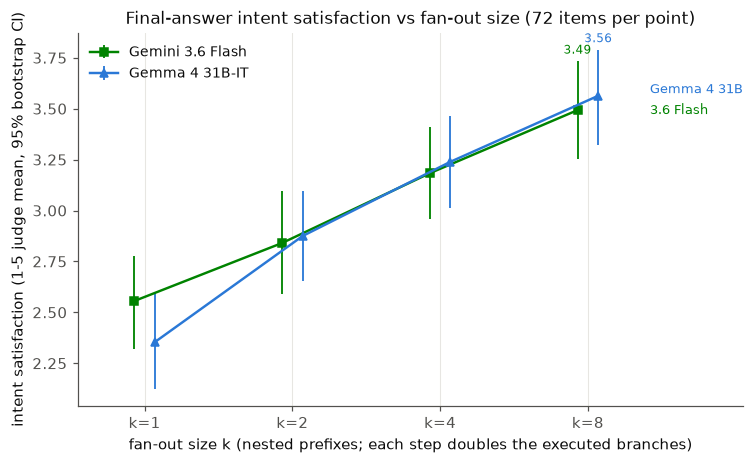

In [4]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
draw_scaling(ax, "final_intent_satisfaction", end_label=True)
name_y = spread([arm_k_stat("final_intent_satisfaction", a, 8)[0] for a in ARMS], 0.10)
for (arm, m), y in zip(ARMS.items(), name_y):
    ax.annotate(m["short"], xy=(XPOS[-1] + 0.42, y),
                fontsize=8.5, color=m["color"], va="center")
ax.set_xlim(-0.45, XPOS[-1] + 1.05)
ax.set_xlabel("fan-out size k (nested prefixes; each step doubles the executed branches)")
ax.set_ylabel("intent satisfaction (1-5 judge mean, 95% bootstrap CI)")
ax.set_title("Final-answer intent satisfaction vs fan-out size (72 items per point)")
ax.legend(loc="upper left", fontsize=9)
style_ax(ax)
save_fig(fig, "c2_intent_scaling")
plt.show()

## 2 · What scales, what saturates

Six final-answer dimensions vs k, grouped into two families. Read whether the
*personalization* family (persona-target use, non-genericness, specificity, constraint
awareness) climbs with k while the *evidence hygiene* family (groundedness, evidence-usage
quality) starts high and saturates — i.e., whether extra branches buy tailoring rather
than correctness.

saved c2_final_metric_grid.pdf/.png -> reports/paper/figures


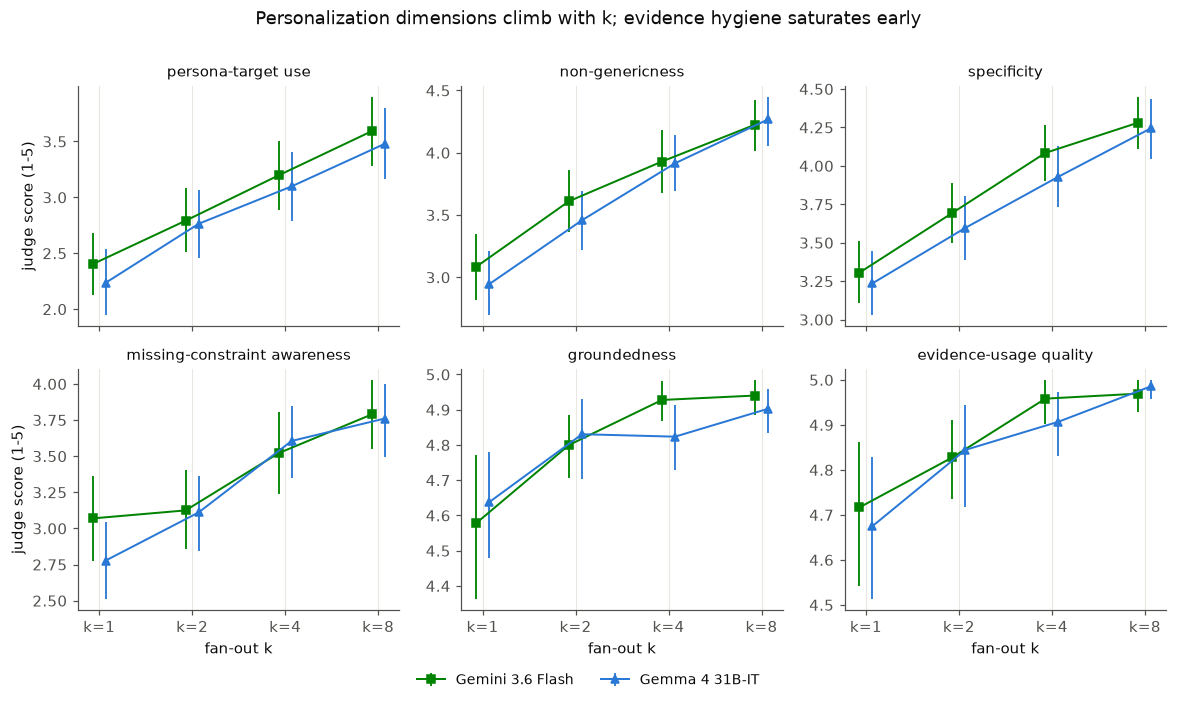

In [5]:
GRID_METRICS = [
    ("final_personalization_target_use", "persona-target use"),
    ("final_non_genericness",            "non-genericness"),
    ("final_specificity",                "specificity"),
    ("final_missing_constraint_awareness", "missing-constraint awareness"),
    ("final_groundedness",               "groundedness"),
    ("final_evidence_usage_quality",     "evidence-usage quality"),
]
fig, axes = plt.subplots(2, 3, figsize=(10.8, 6.0), sharex=True)
for ax, (metric, title) in zip(axes.flat, GRID_METRICS):
    draw_scaling(ax, metric, lw=1.3)
    ax.set_title(title, fontsize=10)
    style_ax(ax)
for ax in axes[1]:
    ax.set_xlabel("fan-out k")
for ax in axes[:, 0]:
    ax.set_ylabel("judge score (1-5)")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=3, loc="lower center", bbox_to_anchor=(0.5, -0.04), fontsize=9)
fig.suptitle("Personalization dimensions climb with k; evidence hygiene saturates early", y=1.005)
fig.tight_layout()
save_fig(fig, "c2_final_metric_grid")
plt.show()

## 3 · Marginal gains per doubling (paired, within arm)

Nested prefixes make each k-doubling a *paired* contrast on the same 72 items:
Δ = score(k↑) − score(k↓) per item, with the pipeline's 95% CI. Read: a whisker right of
the zero line means that doubling reliably helped; compare rows top→bottom to see how much
of the gain each successive doubling still buys. Section 8 prints the exact numbers.

saved c2_marginal_gains.pdf/.png -> reports/paper/figures


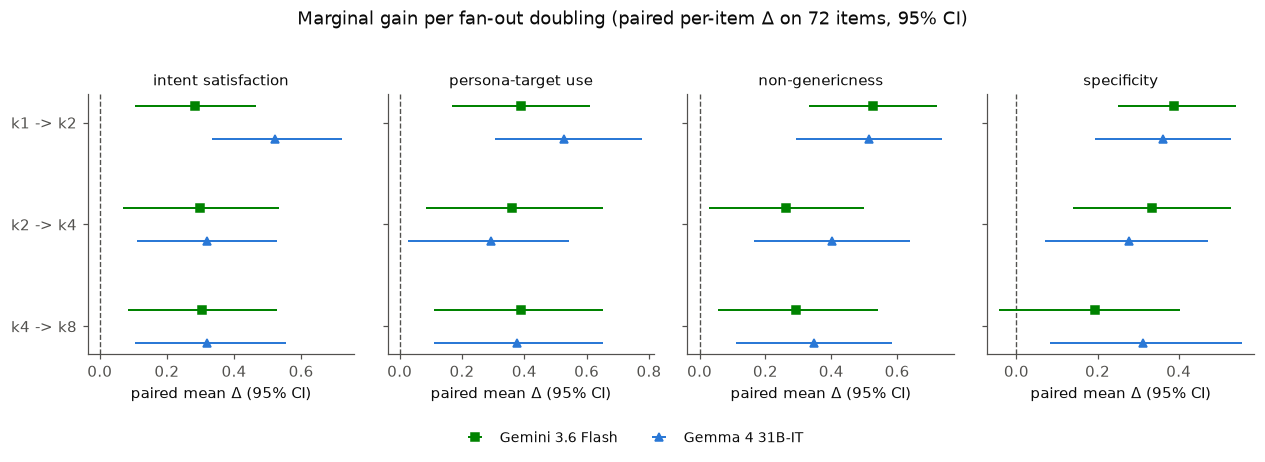

In [6]:
FOREST_METRICS = [
    ("final_intent_satisfaction",       "intent satisfaction"),
    ("final_personalization_target_use", "persona-target use"),
    ("final_non_genericness",           "non-genericness"),
    ("final_specificity",               "specificity"),
]
TRANS = [("k1_to_k2", "k1 -> k2"), ("k2_to_k4", "k2 -> k4"), ("k4_to_k8", "k4 -> k8")]

fig, axes = plt.subplots(1, 4, figsize=(11.6, 3.6), sharey=True)
yb = np.arange(len(TRANS))[::-1]           # top row = first doubling
voff = dict(zip(ARMS, (0.16, -0.16)))
for ax, (metric, title) in zip(axes, FOREST_METRICS):
    ax.axvline(0, color=INK2, lw=0.9, ls="--", zorder=1)
    for arm, m in ARMS.items():
        g = MG[arm].set_index(["comparison", "metric"])
        mus, los, his, ys = [], [], [], []
        for (comp, _), y in zip(TRANS, yb):
            row = g.loc[(comp, metric)]
            mus.append(row.mean_paired_diff); los.append(row.ci95_low); his.append(row.ci95_high)
            ys.append(y + voff[arm])
        mus, los, his = map(np.asarray, (mus, los, his))
        ax.errorbar(mus, ys, xerr=[mus - los, his - mus], fmt=m["marker"], ms=5,
                    color=m["color"], elinewidth=1.3, capsize=0, lw=0,
                    label=m["label"], zorder=3)
    ax.set_title(title, fontsize=10)
    ax.set_yticks(yb, [t[1] for t in TRANS])
    ax.set_xlabel("paired mean Δ (95% CI)")
    style_ax(ax, xgrid=True)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=3, loc="lower center", bbox_to_anchor=(0.5, -0.10), fontsize=9)
fig.suptitle("Marginal gain per fan-out doubling (paired per-item Δ on 72 items, 95% CI)", y=1.03)
fig.tight_layout()
save_fig(fig, "c2_marginal_gains")
plt.show()

## 4 · Mechanism: why more branches help — and why they stop helping

**First figure:** the retrieval channel — do extra branches buy persona-constraint
coverage and persona-fit evidence, the raw material of personalization?
**Second figure:** the overlap mechanism — how far unique documents fall below the
5-results-per-branch no-overlap ceiling, and how the duplicate share moves with k. The gap
between those two curves is the fraction of the search budget spent re-finding documents.

saved c2_retrieval_mechanism.pdf/.png -> reports/paper/figures


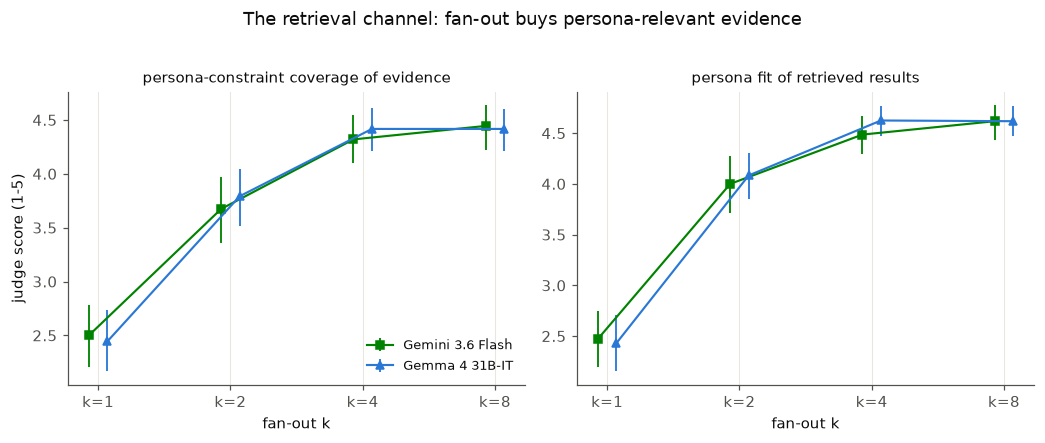

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9), sharex=True)
for ax, (metric, title) in zip(axes, [
        ("retrieval_constraint_coverage", "persona-constraint coverage of evidence"),
        ("retrieval_result_persona_fit",  "persona fit of retrieved results")]):
    draw_scaling(ax, metric, lw=1.4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("fan-out k")
    style_ax(ax)
axes[0].set_ylabel("judge score (1-5)")
axes[0].legend(loc="lower right", fontsize=8.5)
fig.suptitle("The retrieval channel: fan-out buys persona-relevant evidence", y=1.02)
fig.tight_layout()
save_fig(fig, "c2_retrieval_mechanism")
plt.show()

saved c2_dedup_saturation.pdf/.png -> reports/paper/figures


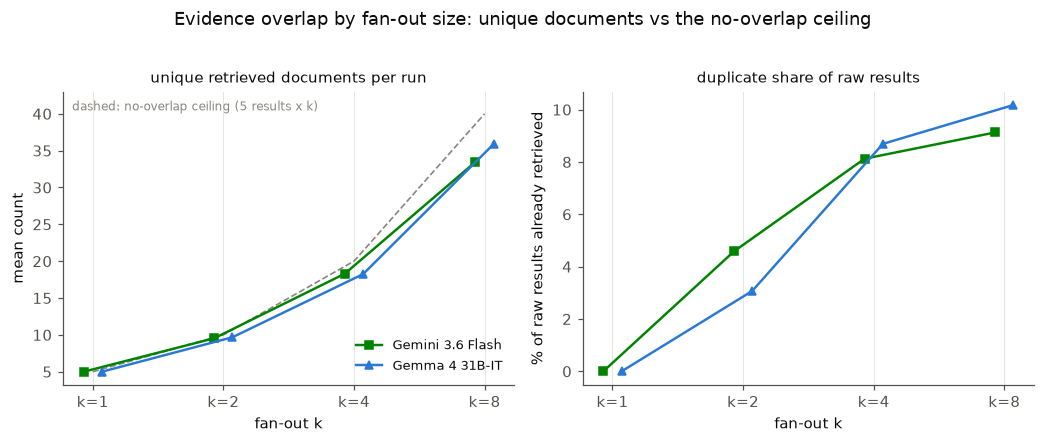

In [8]:
ALL["dup_share"] = np.where(ALL.num_raw_results > 0,
                            1.0 - ALL.num_unique_results / ALL.num_raw_results, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9), sharex=True)
ax = axes[0]
ax.plot(XPOS, [5 * k for k in KS], ls="--", lw=1.1, color=MUTED, zorder=2)
ax.annotate("dashed: no-overlap ceiling (5 results x k)", xy=(0.02, 0.97),
            xycoords="axes fraction", fontsize=8, color=MUTED, ha="left", va="top")
for arm, m in ARMS.items():
    mus = [ALL[(ALL.arm == arm) & (ALL.k == k)].num_unique_results.mean() for k in KS]
    ax.plot(XPOS + OFF[arm], mus, color=m["color"], marker=m["marker"], ms=5.5, lw=1.6,
            label=m["label"], zorder=3)
ax.set_title("unique retrieved documents per run", fontsize=10)
ax.set_ylabel("mean count")
ax.set_xlabel("fan-out k")
ax.set_xticks(XPOS, [f"k={k}" for k in KS])
ax.set_ylim(top=43)
ax.legend(loc="lower right", fontsize=8.5)
style_ax(ax)

ax = axes[1]
for arm, m in ARMS.items():
    mus = [100 * ALL[(ALL.arm == arm) & (ALL.k == k)].dup_share.mean() for k in KS]
    ax.plot(XPOS + OFF[arm], mus, color=m["color"], marker=m["marker"], ms=5.5, lw=1.6, zorder=3)
ax.set_title("duplicate share of raw results", fontsize=10)
ax.set_ylabel("% of raw results already retrieved")
ax.set_xlabel("fan-out k")
ax.set_xticks(XPOS, [f"k={k}" for k in KS])
style_ax(ax)
fig.suptitle("Evidence overlap by fan-out size: unique documents vs the no-overlap ceiling", y=1.02)
fig.tight_layout()
save_fig(fig, "c2_dedup_saturation")
plt.show()

## 5 · Quality–cost frontier: where to operate

Quality (intent satisfaction) against the real cost driver — synthesis context size, which
is what the synthesizer must read (∝ prompt tokens; Tavily calls scale trivially as k).
Each arm traces its k-path left→right; the knee of the path is the natural operating point,
and Section 8 computes the smallest k statistically indistinguishable from k=8.

saved c2_quality_cost_frontier.pdf/.png -> reports/paper/figures


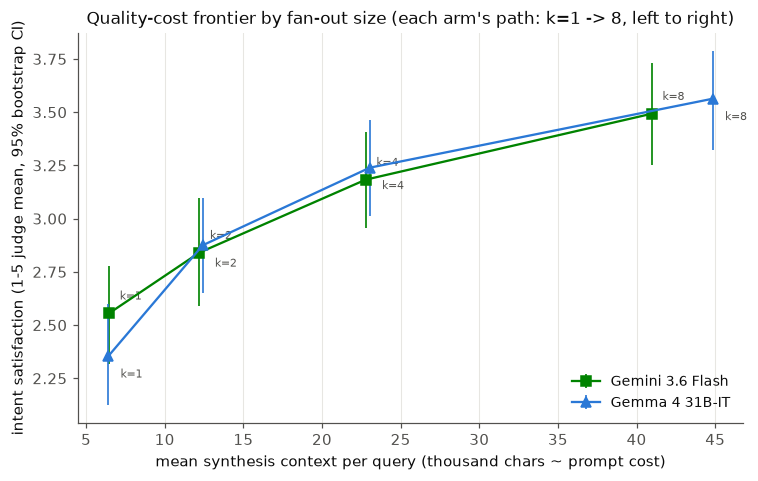

In [9]:
fig, ax = plt.subplots(figsize=(7.8, 4.6))
# hand-placed label offsets so no k-label collides with a neighboring arm's
K_OFFSETS = {
    "gemini-3.6-flash": {k: (7, 9) for k in KS},
    "gemma-4-31b-it":   {k: (8, -14) for k in KS},
}
for arm, m in ARMS.items():
    xs, ys, ylo, yhi = [], [], [], []
    for k in KS:
        sub = ALL[(ALL.arm == arm) & (ALL.k == k)]
        mu, lo, hi = boot_mean_ci(sub.final_intent_satisfaction)
        xs.append(sub.total_synthesis_context_size.mean() / 1000)
        ys.append(mu); ylo.append(mu - lo); yhi.append(hi - mu)
    ax.errorbar(xs, ys, yerr=[ylo, yhi], color=m["color"], marker=m["marker"], ms=6,
                lw=1.5, elinewidth=1.1, capsize=0, label=m["label"], zorder=3)
    for x, y, k in zip(xs, ys, KS):
        ax.annotate(f"k={k}", (x, y), textcoords="offset points",
                    xytext=K_OFFSETS[arm][k], fontsize=7.5, color=INK2)
ax.set_xlabel("mean synthesis context per query (thousand chars ~ prompt cost)")
ax.set_ylabel("intent satisfaction (1-5 judge mean, 95% bootstrap CI)")
ax.set_title("Quality-cost frontier by fan-out size (each arm's path: k=1 -> 8, left to right)")
ax.legend(loc="lower right", fontsize=9)
style_ax(ax)
save_fig(fig, "c2_quality_cost_frontier")
plt.show()

## 6 · Does the story hold across domains?

Same headline curve, split by macro-domain (24 items per point — wider CIs, read shapes
not decimals). Checks that scaling gains aren't carried by a single domain.

saved c2_domain_scaling.pdf/.png -> reports/paper/figures


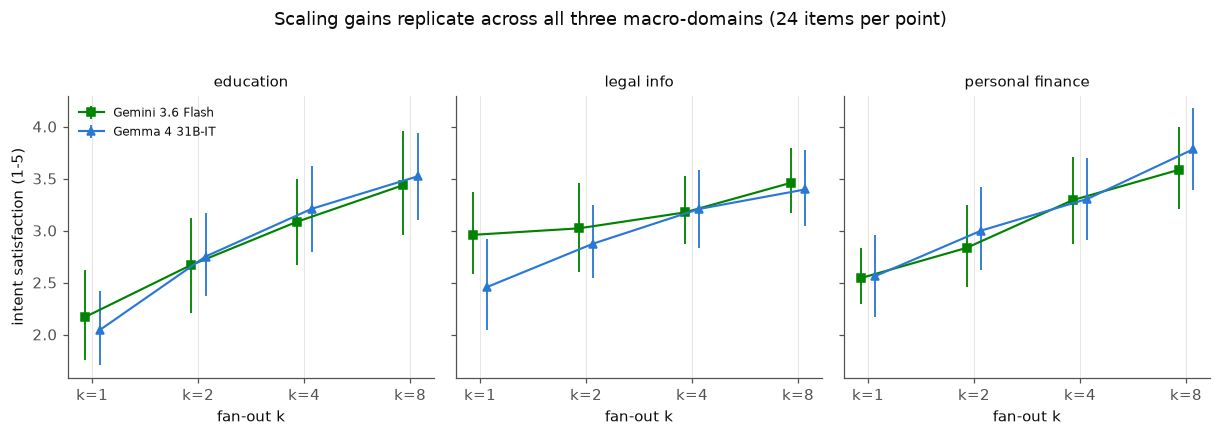

In [10]:
DOMAINS = sorted(ALL.macro_domain.unique())
fig, axes = plt.subplots(1, len(DOMAINS), figsize=(11.2, 3.8), sharey=True)
for ax, dom in zip(axes, DOMAINS):
    draw_scaling(ax, "final_intent_satisfaction", sub=ALL[ALL.macro_domain == dom], lw=1.4)
    ax.set_title(dom.replace("_", " "), fontsize=10)
    ax.set_xlabel("fan-out k")
    style_ax(ax)
axes[0].set_ylabel("intent satisfaction (1-5)")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Scaling gains replicate across all three macro-domains (24 items per point)", y=1.03)
fig.tight_layout()
save_fig(fig, "c2_domain_scaling")
plt.show()

## 7 · Paper tables

**Main table** — per arm × k: headline judge scores (mean, 95% bootstrap CI) and cost
(searches, synthesis context, latency). **Marginal table** — paired per-item Δ per doubling
with CI and % of items improved. CSVs keep full precision; `.tex` files are formatted.

In [11]:
TAB_METRICS = [
    ("final_intent_satisfaction",        "intent"),
    ("final_personalization_target_use", "persona use"),
    ("final_non_genericness",            "non-generic"),
    ("final_groundedness",               "grounded"),
]
rows = []
for arm, meta in ARMS.items():
    for k in KS:
        sub = ALL[(ALL.arm == arm) & (ALL.k == k)]
        r = dict(planner=meta["short"], k=k)
        for metric, name in TAB_METRICS:
            mu, lo, hi = boot_mean_ci(sub[metric])
            r[name] = mu; r[f"{name}_lo"] = lo; r[f"{name}_hi"] = hi
        r["searches"] = sub.num_tavily_calls.mean()
        r["synth_kchars"] = sub.total_synthesis_context_size.mean() / 1000
        r["latency_s"] = sub.total_latency.mean()
        rows.append(r)
main_tab = pd.DataFrame(rows)
main_tab.to_csv(TAB_DIR / "c2_main_scaling.csv", index=False)

pretty = main_tab[["planner", "k"]].copy()
for _, name in TAB_METRICS:
    pretty[name] = [f"{m:.2f} [{l:.2f}, {h:.2f}]" for m, l, h in
                    zip(main_tab[name], main_tab[f"{name}_lo"], main_tab[f"{name}_hi"])]
pretty["searches"] = main_tab.searches.map("{:.0f}".format)
pretty["synth ctx (k chars)"] = main_tab.synth_kchars.map("{:.1f}".format)
pretty["latency (s)"] = main_tab.latency_s.map("{:.0f}".format)
(TAB_DIR / "c2_main_scaling.tex").write_text(
    pretty.to_latex(index=False, escape=True, column_format="ll" + "r" * (pretty.shape[1] - 2)))
print("saved c2_main_scaling.csv/.tex ->", TAB_DIR.relative_to(ROOT))
pretty

saved c2_main_scaling.csv/.tex -> reports/paper/tables


,planner,k,intent,persona use,non-generic,grounded,searches,synth ctx (k chars),latency (s)
0,3.6 Flash,1,"2.56 [2.32, 2.78]","2.40 [2.12, 2.68]","3.08 [2.82, 3.35]","4.58 [4.36, 4.77]",1,6.5,31
1,3.6 Flash,2,"2.84 [2.59, 3.10]","2.79 [2.51, 3.08]","3.61 [3.36, 3.86]","4.80 [4.71, 4.89]",2,12.2,42
2,3.6 Flash,4,"3.18 [2.96, 3.41]","3.20 [2.89, 3.51]","3.93 [3.68, 4.18]","4.93 [4.87, 4.98]",4,22.8,68
3,3.6 Flash,8,"3.49 [3.25, 3.73]","3.59 [3.28, 3.90]","4.23 [4.01, 4.42]","4.94 [4.88, 4.98]",8,41.0,127
4,Gemma 4 31B,1,"2.35 [2.12, 2.60]","2.24 [1.94, 2.54]","2.94 [2.69, 3.21]","4.64 [4.48, 4.78]",1,6.4,66
5,Gemma 4 31B,2,"2.88 [2.65, 3.10]","2.76 [2.46, 3.07]","3.46 [3.22, 3.69]","4.83 [4.70, 4.93]",2,12.4,69
6,Gemma 4 31B,4,"3.24 [3.01, 3.46]","3.10 [2.79, 3.41]","3.92 [3.69, 4.14]","4.82 [4.73, 4.91]",4,23.0,73
7,Gemma 4 31B,8,"3.56 [3.32, 3.79]","3.48 [3.17, 3.80]","4.27 [4.06, 4.45]","4.90 [4.83, 4.96]",8,44.8,85


In [12]:
mg_rows = []
for arm, meta in ARMS.items():
    g = MG[arm].set_index(["comparison", "metric"])
    for comp, lab in TRANS + [("k1_to_k8", "k1 -> k8 (total)")]:
        for metric, name in [("final_intent_satisfaction", "intent"),
                             ("final_personalization_target_use", "persona use")]:
            row = g.loc[(comp, metric)]
            mg_rows.append(dict(
                planner=meta["short"], step=lab, metric=name,
                delta=row.mean_paired_diff, ci_lo=row.ci95_low, ci_hi=row.ci95_high,
                pct_improved=row.pct_improved))
mg_tab = pd.DataFrame(mg_rows)
mg_tab.to_csv(TAB_DIR / "c2_marginal_gains.csv", index=False)

mg_pretty = mg_tab.copy()
mg_pretty["Δ [95% CI]"] = [f"{d:+.2f} [{l:+.2f}, {h:+.2f}]"
                           for d, l, h in zip(mg_tab.delta, mg_tab.ci_lo, mg_tab.ci_hi)]
mg_pretty["% items improved"] = mg_tab.pct_improved.map("{:.0f}%".format)
mg_pretty = mg_pretty[["planner", "step", "metric", "Δ [95% CI]", "% items improved"]]
(TAB_DIR / "c2_marginal_gains.tex").write_text(
    mg_pretty.to_latex(index=False, escape=True, column_format="lllrr"))
print("saved c2_marginal_gains.csv/.tex ->", TAB_DIR.relative_to(ROOT))
mg_pretty[mg_pretty.metric == "intent"]

saved c2_marginal_gains.csv/.tex -> reports/paper/tables


,planner,step,metric,Δ [95% CI],% items improved
0,3.6 Flash,k1 -> k2,intent,"+0.28 [+0.10, +0.47]",38%
2,3.6 Flash,k2 -> k4,intent,"+0.30 [+0.07, +0.53]",31%
4,3.6 Flash,k4 -> k8,intent,"+0.31 [+0.08, +0.53]",36%
6,3.6 Flash,k1 -> k8 (total),intent,"+0.89 [+0.64, +1.13]",67%
8,Gemma 4 31B,k1 -> k2,intent,"+0.52 [+0.33, +0.72]",39%
10,Gemma 4 31B,k2 -> k4,intent,"+0.32 [+0.11, +0.53]",33%
12,Gemma 4 31B,k4 -> k8,intent,"+0.32 [+0.10, +0.56]",36%
14,Gemma 4 31B,k1 -> k8 (total),intent,"+1.16 [+0.90, +1.40]",68%


## 8 · Computed takeaways (auto-refresh with the data)

Every number below is recomputed from the loaded runs, so this cell stays truthful after
the quota-redo re-run. Use these as the skeleton of the C2 results paragraph.

In [13]:
lines = []
for arm, meta in ARMS.items():
    g = MG[arm].set_index(["comparison", "metric"])
    tot = g.loc[("k1_to_k8", "final_intent_satisfaction")]
    last = g.loc[("k4_to_k8", "final_intent_satisfaction")]
    steps = {c: g.loc[(c, "final_intent_satisfaction")].mean_paired_diff for c, _ in TRANS}
    big = max(steps, key=steps.get)
    cost8 = ALL[(ALL.arm == arm) & (ALL.k == 8)].total_synthesis_context_size.mean()
    cost1 = ALL[(ALL.arm == arm) & (ALL.k == 1)].total_synthesis_context_size.mean()
    dup8 = 100 * ALL[(ALL.arm == arm) & (ALL.k == 8)].dup_share.mean()
    mu8, lo8, _ = arm_k_stat("final_intent_satisfaction", arm, 8)
    knee = next((k for k in KS if arm_k_stat("final_intent_satisfaction", arm, k)[2] >= lo8), 8)
    lines.append(
        f"{meta['label']}:\n"
        f"  k1->k8 intent gain {tot.mean_paired_diff:+.2f} [{tot.ci95_low:+.2f}, {tot.ci95_high:+.2f}] "
        f"({tot.pct_improved:.0f}% of items improved); largest single step: {big.replace('_', ' ')} "
        f"({steps[big]:+.2f}); final doubling k4->k8: {last.mean_paired_diff:+.2f} "
        f"[{last.ci95_low:+.2f}, {last.ci95_high:+.2f}]\n"
        f"  cost: k8 reads {cost8 / cost1:.1f}x the synthesis context of k1; "
        f"{dup8:.0f}% of k8 raw results are duplicates\n"
        f"  smallest k whose intent CI overlaps k8's: k={knee}")
print("\n\n".join(lines))

Gemini 3.6 Flash:
  k1->k8 intent gain +0.89 [+0.64, +1.13] (67% of items improved); largest single step: k4 to k8 (+0.31); final doubling k4->k8: +0.31 [+0.08, +0.53]
  cost: k8 reads 6.3x the synthesis context of k1; 9% of k8 raw results are duplicates
  smallest k whose intent CI overlaps k8's: k=4

Gemma 4 31B-IT:
  k1->k8 intent gain +1.16 [+0.90, +1.40] (68% of items improved); largest single step: k1 to k2 (+0.52); final doubling k4->k8: +0.32 [+0.10, +0.56]
  cost: k8 reads 7.0x the synthesis context of k1; 10% of k8 raw results are duplicates
  smallest k whose intent CI overlaps k8's: k=4
